
# Module 22: XGBoost  
## XGBoost Training, Prediction, Implementation, Evaluation & Use Cases



## 22.3 XGBoost Training, Prediction & Key Parameters

### How XGBoost Training Works (Big Picture)

XGBoost training follows a disciplined correction loop:

1. Start with an initial prediction (base score)
2. Compute gradients and hessians
3. Build a tree that minimizes the objective
4. Compute optimal leaf weights
5. Update predictions using learning rate
6. Repeat until performance stops improving

> Key idea: **Each tree is weak on purpose. Strength comes from many controlled corrections.**



### XGBoost Prediction Formula

The final prediction is:

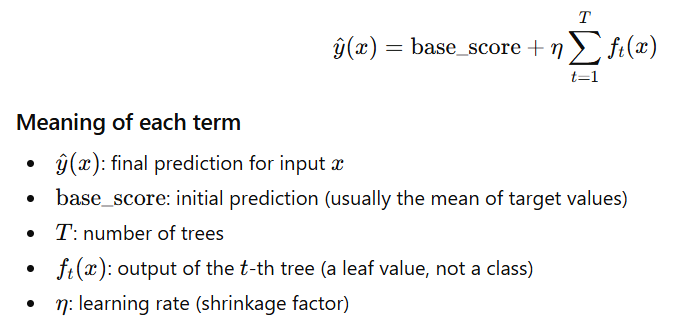\[


> Prediction is the **sum of all trees**, not the last tree.



### Key Parameters You Must Understand

#### Core Structure
- `n_estimators`: number of trees  
- `max_depth`: depth of each tree  
- `learning_rate (eta)`: step size of updates  

Golden rule:
> High depth + high learning rate = overfitting speedrun



#### Regularization Parameters (XGBoost Superpower)

- `gamma`: minimum gain required for a split
- `reg_lambda`: L2 penalty on leaf weights
- `reg_alpha`: L1 penalty (sparsity)

These prevent XGBoost from memorizing noise.



#### Sampling Parameters

- `subsample`: fraction of rows used per tree
- `colsample_bytree`: fraction of features used per tree

> Sampling intentionally hides data to reduce overfitting.



#### Objective Function

Examples:
- `reg:squarederror` → regression
- `binary:logistic` → binary classification
- `multi:softprob` → multiclass classification

> Wrong objective = wrong math = useless model



## 22.4 Implementing XGBoost on a Dataset

We will use a **binary classification dataset** so evaluation concepts are meaningful.


In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier


### Load Dataset

This dataset predicts whether a tumor is:
- 0 = malignant
- 1 = benign


In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)


### Train-Test Split

We use stratification to preserve class balance.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Train a Baseline XGBoost Model

This is a **sane default**, not hyperparameter tuning.


In [4]:
#Deafult XGBoost Model
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


### Prediction

- `predict` gives class labels  
- `predict_proba` gives confidence scores


In [5]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


## 22.5 Model Evaluation, Model Selection & Practical Use Cases



### Evaluation Metrics

Accuracy alone is dangerous. Always inspect precision and recall.


In [6]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114




### Confusion Matrix

Interpret errors, not just numbers.


In [7]:
confusion_matrix(y_test, y_pred)

array([[39,  3],
       [ 1, 71]])


### Early Stopping (Overfitting Control)

Early stopping halts training when validation performance stops improving.


In [9]:
#Early Stopping (Overfitting Control)
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 3,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

modelr = xgb.train(
    params = params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=[(dtest,"eval")],
    early_stopping_rounds=20
)

[0]	eval-logloss:0.61842
[1]	eval-logloss:0.58321
[2]	eval-logloss:0.55104
[3]	eval-logloss:0.52092
[4]	eval-logloss:0.49485
[5]	eval-logloss:0.46980
[6]	eval-logloss:0.44583
[7]	eval-logloss:0.42668
[8]	eval-logloss:0.40677
[9]	eval-logloss:0.38936
[10]	eval-logloss:0.37125
[11]	eval-logloss:0.35560
[12]	eval-logloss:0.34238
[13]	eval-logloss:0.32902
[14]	eval-logloss:0.31743
[15]	eval-logloss:0.30605
[16]	eval-logloss:0.29459
[17]	eval-logloss:0.28525
[18]	eval-logloss:0.27401
[19]	eval-logloss:0.26437
[20]	eval-logloss:0.25546
[21]	eval-logloss:0.24706
[22]	eval-logloss:0.24009
[23]	eval-logloss:0.23212
[24]	eval-logloss:0.22329
[25]	eval-logloss:0.21754
[26]	eval-logloss:0.21184
[27]	eval-logloss:0.20431
[28]	eval-logloss:0.19901
[29]	eval-logloss:0.19339
[30]	eval-logloss:0.18912
[31]	eval-logloss:0.18470
[32]	eval-logloss:0.17945
[33]	eval-logloss:0.17579
[34]	eval-logloss:0.17142
[35]	eval-logloss:0.16806
[36]	eval-logloss:0.16374
[37]	eval-logloss:0.16007
[38]	eval-logloss:0.15

In [10]:
y_prob = modelr.predict(dtest)

y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print("Accuracy: ", acc)

Accuracy:  0.956140350877193


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [12]:
print("Early Stopping Information: ")
print("Best Iteration:", modelr.best_iteration)
print("Best score [logloss]: ", modelr.best_score)

Early Stopping Information: 
Best Iteration: 146
Best score [logloss]:  0.08581996162058458



### Feature Importance

Importance indicates contribution, not causation.


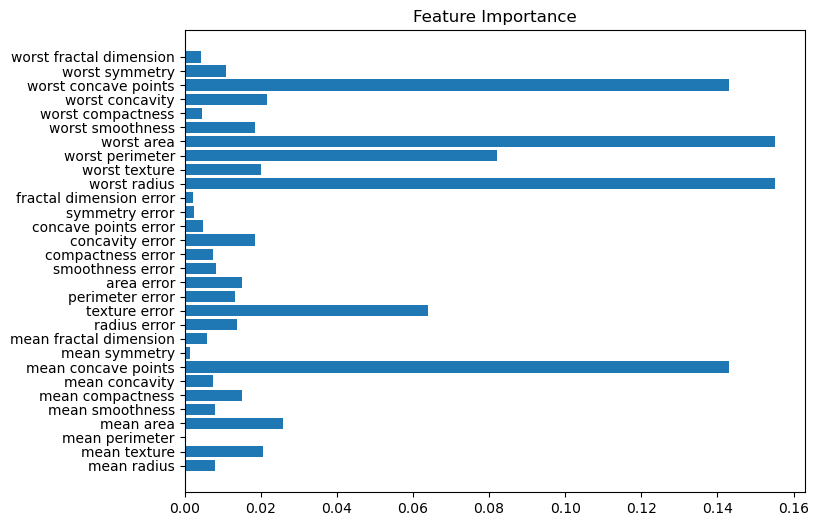

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.show()